In [ ]:
# Notebook 06 — Análisis de Redes (Co-ocurrencia de Entidades)

**Reto 7 — Análisis de Datos No Estructurados y Redes Sociales**

## 🎯 Objetivo
1. Construir la **red de co-ocurrencia de entidades** mencionadas en los tweets.
2. Analizar la **topología** de la red: componentes, densidad, centralidades.
3. Detectar **comunidades** con el algoritmo de Louvain.
4. Identificar entidades **influyentes** (hubs) y **puentes** entre comunidades.
5. Visualizar la red y extraer insights accionables.

## 📌 Input
- `data/processed/tweets_entidades_20260920.csv`

## 📌 Output
- `data/processed/red_entidades_nodos_YYYYMMDD.csv`
- `data/processed/red_entidades_aristas_YYYYMMDD.csv`
- `data/processed/red_entidades_comunidades_YYYYMMDD.csv`
- `outputs/figuras/06_*.png`
- `outputs/reportes/06_redes_resumen.md`

In [1]:
# ============================================
# Imports y configuración
# ============================================
import ast
import warnings
from pathlib import Path
from datetime import datetime
from itertools import combinations
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import networkx as nx

# Detección de comunidades
try:
    import community as community_louvain  # python-louvain
    LOUVAIN_OK = True
    print("✅ python-louvain disponible")
except ImportError:
    LOUVAIN_OK = False
    print("⚠️ python-louvain no instalado → pip install python-louvain")

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 150)
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

# --- Rutas ---
def encontrar_raiz_proyecto():
    cwd = Path.cwd()
    for candidato in [cwd, cwd.parent, cwd.parent.parent, cwd.parent.parent.parent]:
        if (candidato / "requirements.txt").exists() and (candidato / "data").exists():
            return candidato
    return cwd.parent

BASE_DIR = encontrar_raiz_proyecto()
DATA_PROCESSED = BASE_DIR / "data" / "processed"
FIGURAS = BASE_DIR / "outputs" / "figuras"
REPORTES = BASE_DIR / "outputs" / "reportes"

FIGURAS.mkdir(parents=True, exist_ok=True)
REPORTES.mkdir(parents=True, exist_ok=True)

print(f"📁 BASE_DIR: {BASE_DIR}")

✅ python-louvain disponible
📁 BASE_DIR: C:\Users\jdthg\Documents\curso6BI\reto7_Analisis_datos_no_estructurados


In [2]:
# ============================================
# Cargar dataset de entidades
# ============================================
archivos = sorted(
    DATA_PROCESSED.glob("tweets_entidades_*.csv"),
    key=lambda x: x.stat().st_mtime,
    reverse=True,
)

if not archivos:
    raise FileNotFoundError("❌ No se encontró tweets_entidades_*.csv")

RUTA = archivos[0]
print(f"📂 Cargando: {RUTA.name}")
df = pd.read_csv(RUTA, encoding="utf-8-sig")

print(f"✅ Shape: {df.shape}")
print(f"📋 Columnas: {list(df.columns)}")
display(df.head(3))

📂 Cargando: tweets_entidades_20260920.csv
✅ Shape: (100000, 3)
📋 Columnas: ['texto_limpio', 'sentimiento_vader', 'entidades']


,texto_limpio,sentimiento_vader,entidades
0,free ai marketing and automation tools strategies and collaboration launching new week chatgpt,positivo,[]
1,chat gpt says it s,neutral,"[('gpt', 'ORG')]"
2,chat with any pdf check out how this new ai quickly answers questions from your pdfs perfect for students researchers and other curious minds rese...,positivo,[]


In [3]:
# ============================================
# Parsear la columna 'entidades'
# ============================================
def parse_entidades(x):
    """Convierte string tipo "[('OpenAI', 'ORG'), ...]" a lista."""
    if isinstance(x, list):
        return x
    if isinstance(x, str) and x.strip():
        try:
            return ast.literal_eval(x)
        except (ValueError, SyntaxError):
            return []
    return []

df["entidades_parsed"] = df["entidades"].apply(parse_entidades)

# Estadísticas
n_ents = df["entidades_parsed"].str.len().sum()
n_con_ents = (df["entidades_parsed"].str.len() > 0).sum()

print(f"📊 Tweets con entidades: {n_con_ents:,} ({n_con_ents/len(df)*100:.1f}%)")
print(f"📊 Total entidades: {n_ents:,}")
print(f"\n👀 Ejemplo:")
print(df["entidades_parsed"].iloc[0])

📊 Tweets con entidades: 48,494 (48.5%)
📊 Total entidades: 64,268

👀 Ejemplo:
[]


In [4]:
# ============================================
# Filtrar entidades por tipo y frecuencia
# ============================================
# Tipos a incluir (excluimos GPE para una red temática más limpia,
# como acordamos; puedes añadirlo si quieres contexto geográfico)
TIPOS_INCLUIDOS = {"ORG", "PERSON", "PRODUCT"}

# Umbral mínimo de apariciones por entidad
MIN_FREQ = 20

# Contar frecuencia de cada entidad
counter = Counter()
for ents in df["entidades_parsed"]:
    for ent, tipo in ents:
        if tipo in TIPOS_INCLUIDOS:
            counter[ent] += 1

# Filtrar entidades frecuentes
entidades_validas = {e for e, c in counter.items() if c >= MIN_FREQ}

print(f"📊 Entidades únicas (todos los tipos): {len(counter):,}")
print(f"📊 Entidades en tipos {TIPOS_INCLUIDOS}: {sum(1 for e,t in [x for ents in df['entidades_parsed'] for x in ents] if t in TIPOS_INCLUIDOS):,}")
print(f"📊 Entidades con ≥ {MIN_FREQ} apariciones: {len(entidades_validas):,}")

# Top 20 entidades
top20 = counter.most_common(20)
print(f"\n📋 Top 20 entidades más frecuentes:")
for ent, c in top20:
    print(f"   {ent:30s} {c:>6,}")

📊 Entidades únicas (todos los tipos): 9,677
📊 Entidades en tipos {'ORG', 'PERSON', 'PRODUCT'}: 56,834
📊 Entidades con ≥ 20 apariciones: 84

📋 Top 20 entidades más frecuentes:
   gpt                            33,279
   google                          1,389
   microsoft                       1,079
   don                               982
   doesn                             554
   sam altman                        381
   gpt gpt                           302
   gm                                229
   chatgpt                           191
   midjourney openai                 162
   google s                          160
   chatgpt gpt                       143
   gpt doesn                         124
   microsoft s                       117
   karachi khi                       106
   chatgpt s                         105
   seo                               103
   devs                              100
   noun                              100
   google s bard                      93


In [5]:
# ============================================
# Construir red de co-ocurrencia
# ============================================
# Grafo no dirigido y ponderado
G = nx.Graph()

# Añadir nodos con frecuencia como atributo
for ent in entidades_validas:
    G.add_node(ent, freq=counter[ent], tipo=None)

# Asignar tipo (el más común) a cada nodo
tipo_por_entidad = {}
for ents in df["entidades_parsed"]:
    for ent, tipo in ents:
        if ent in entidades_validas:
            tipo_por_entidad.setdefault(ent, Counter())[tipo] += 1

for ent, tipos in tipo_por_entidad.items():
    G.nodes[ent]["tipo"] = tipos.most_common(1)[0][0]

# Añadir aristas (co-ocurrencias)
# Para cada tweet, combinar entidades válidas en pares
conteo_pares = Counter()

for ents in df["entidades_parsed"]:
    entidades_tweet = list({e for e, _ in ents if e in entidades_validas})
    for par in combinations(sorted(entidades_tweet), 2):
        conteo_pares[par] += 1

# Añadir aristas al grafo (con peso)
for (a, b), peso in conteo_pares.items():
    G.add_edge(a, b, weight=peso)

print(f"✅ Red construida")
print(f"📊 Nodos: {G.number_of_nodes():,}")
print(f"📊 Aristas: {G.number_of_edges():,}")
print(f"📊 Densidad: {nx.density(G):.5f}")

# Componentes conexas
componentes = sorted(nx.connected_components(G), key=len, reverse=True)
print(f"\n📊 Componentes conexas: {len(componentes):,}")
print(f"📊 Componente gigante: {len(componentes[0]):,} nodos")
print(f"📊 Tamaño resto: {sum(len(c) for c in componentes[1:]):,} nodos")

✅ Red construida
📊 Nodos: 84
📊 Aristas: 254
📊 Densidad: 0.07286

📊 Componentes conexas: 8
📊 Componente gigante: 77 nodos
📊 Tamaño resto: 7 nodos


In [6]:
# ============================================
# Extraer componente gigante para análisis posterior
# ============================================
# (Las componentes pequeñas suelen ser ruido)
comp_gigante = max(nx.connected_components(G), key=len)
G_main = G.subgraph(comp_gigante).copy()

print(f"✅ Componente gigante extraída")
print(f"📊 Nodos: {G_main.number_of_nodes():,}")
print(f"📊 Aristas: {G_main.number_of_edges():,}")
print(f"📊 % del total: {G_main.number_of_nodes()/G.number_of_nodes()*100:.1f}%")

# ¿Es conexo?
print(f"📊 ¿Es conexo? {nx.is_connected(G_main)}")

# Diámetro aproximado (puede ser lento; usamos la componente más grande)
try:
    diametro = nx.diameter(G_main)
    print(f"📊 Diámetro: {diametro}")
except Exception as e:
    print(f"⚠️ No se pudo calcular el diámetro: {e}")

✅ Componente gigante extraída
📊 Nodos: 77
📊 Aristas: 254
📊 % del total: 91.7%
📊 ¿Es conexo? True
📊 Diámetro: 4


In [7]:
# ============================================
# Cálculo de centralidades
# ============================================
print("🧠 Calculando centralidades...")

# Grado (ponderado y no ponderado)
degree = dict(G_main.degree())
degree_w = dict(G_main.degree(weight="weight"))

# Betweenness (importante como puente)
betweenness = nx.betweenness_centrality(G_main, weight="weight", seed=42)

# Closeness
closeness = nx.closeness_centrality(G_main)

# Eigenvector (importancia por conexión a otros importantes)
try:
    eigenvector = nx.eigenvector_centrality(G_main, max_iter=1000, weight="weight")
except Exception:
    eigenvector = {}

# DataFrame resumen
df_centralidad = pd.DataFrame({
    "entidad": list(G_main.nodes()),
    "tipo": [G_main.nodes[n]["tipo"] for n in G_main.nodes()],
    "freq": [G_main.nodes[n]["freq"] for n in G_main.nodes()],
    "grado": [degree[n] for n in G_main.nodes()],
    "grado_ponderado": [degree_w[n] for n in G_main.nodes()],
    "betweenness": [betweenness[n] for n in G_main.nodes()],
    "closeness": [closeness[n] for n in G_main.nodes()],
    "eigenvector": [eigenvector.get(n, 0) for n in G_main.nodes()],
}).sort_values("grado_ponderado", ascending=False)

print(f"✅ Centralidades calculadas")
print(f"\n📋 Top 15 por grado ponderado:")
display(df_centralidad.head(15))

🧠 Calculando centralidades...
✅ Centralidades calculadas

📋 Top 15 por grado ponderado:


,entidad,tipo,freq,grado,grado_ponderado,betweenness,closeness,eigenvector
64,gpt,ORG,33279,69,2344,0.324119,0.915663,0.683522
73,google,ORG,1389,31,521,0.134037,0.617886,0.403976
76,microsoft,ORG,1079,34,447,0.080103,0.633333,0.317105
43,don,PERSON,982,31,342,0.272797,0.617886,0.315444
54,doesn,PERSON,554,22,242,0.175846,0.575758,0.230570
69,sam altman,PERSON,381,15,206,0.085016,0.542857,0.203325
3,gpt gpt,ORG,302,12,157,0.058004,0.531469,0.154073
38,gm,ORG,229,8,133,0.008947,0.517007,0.134102
20,google s,PRODUCT,160,7,68,0.006579,0.506667,0.055407
6,chatgpt plus premium account,ORG,62,1,62,0.000000,0.481013,0.067791


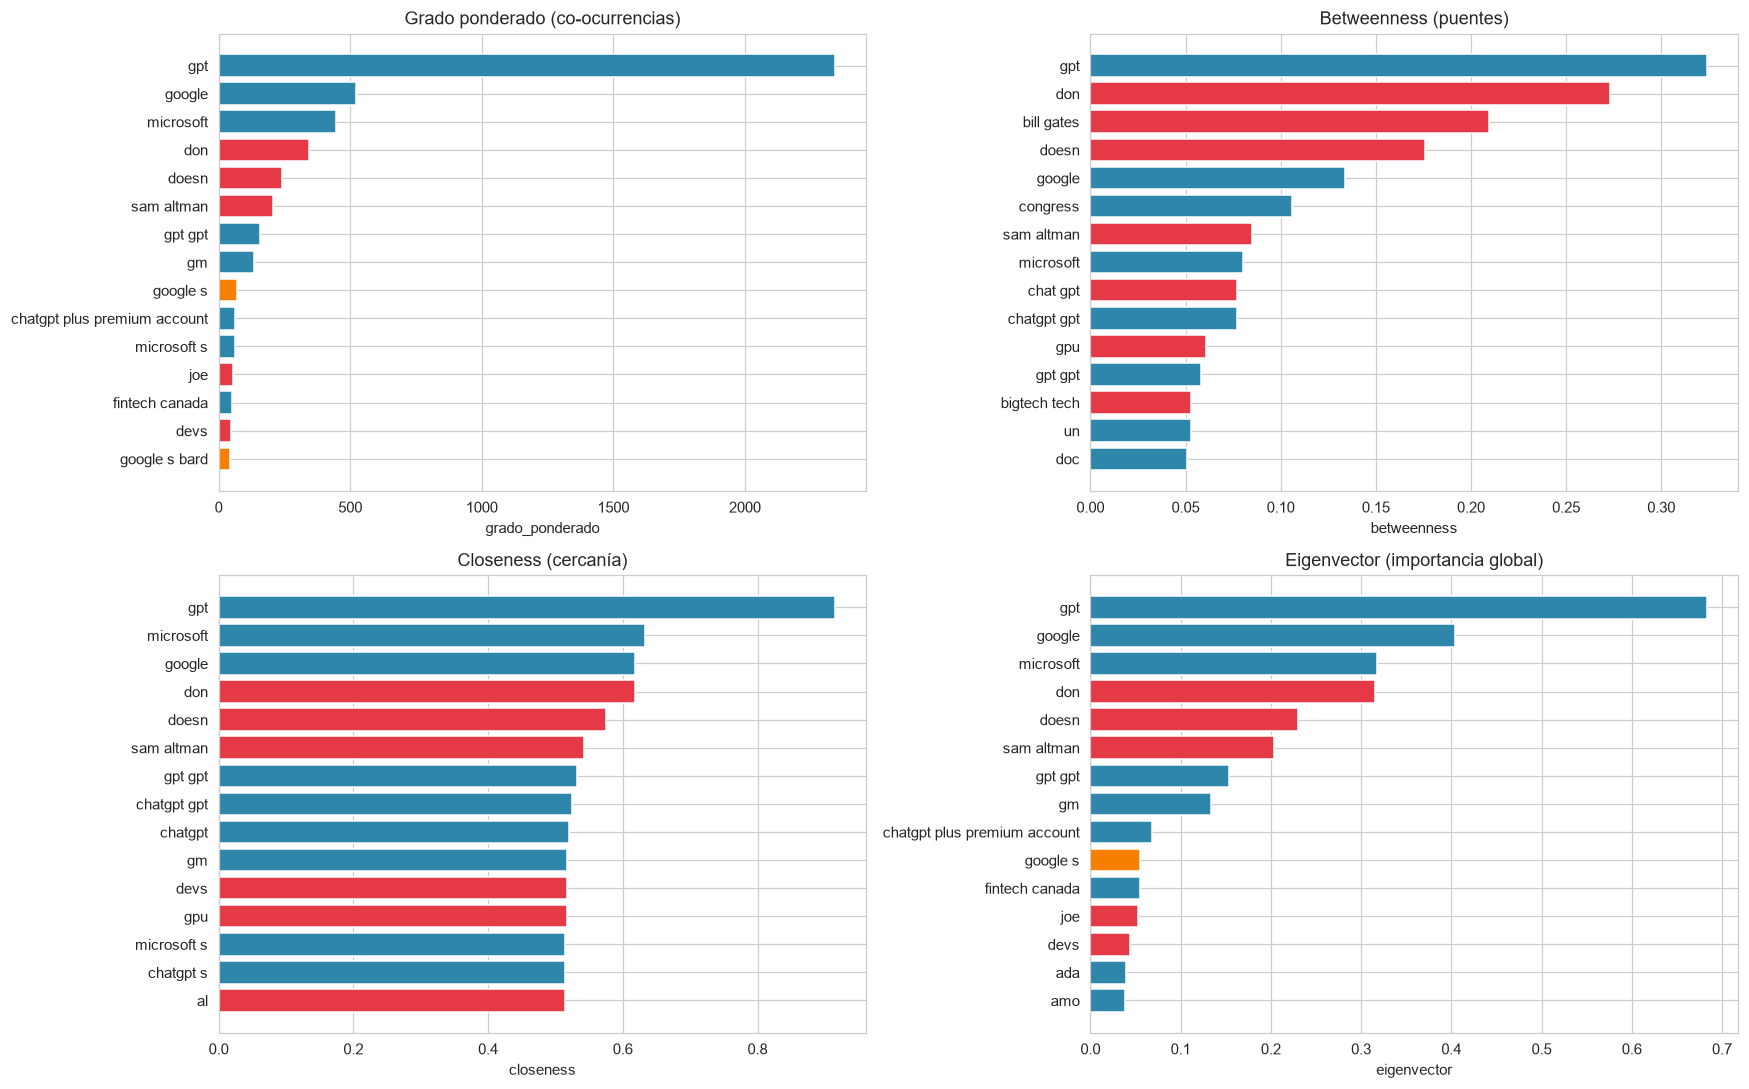

✅ Guardado: C:\Users\jdthg\Documents\curso6BI\reto7_Analisis_datos_no_estructurados\outputs\figuras\06_top_centralidades.png


In [8]:
# ============================================
# Top nodos por cada métrica
# ============================================
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

metricas = [
    ("grado_ponderado", "Grado ponderado (co-ocurrencias)"),
    ("betweenness", "Betweenness (puentes)"),
    ("closeness", "Closeness (cercanía)"),
    ("eigenvector", "Eigenvector (importancia global)"),
]

for ax, (metrica, titulo) in zip(axes, metricas):
    top = df_centralidad.nlargest(15, metrica)

    colores = top["tipo"].map({
        "ORG": "#2E86AB",
        "PERSON": "#E63946",
        "PRODUCT": "#F77F00",
    }).fillna("#888")

    ax.barh(top["entidad"][::-1], top[metrica][::-1], color=colores[::-1])
    ax.set_title(titulo, fontsize=12)
    ax.set_xlabel(metrica)

plt.tight_layout()
ruta_fig = FIGURAS / "06_top_centralidades.png"
plt.savefig(ruta_fig, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Guardado: {ruta_fig}")

In [9]:
# ============================================
# Detección de comunidades con Louvain
# ============================================
if LOUVAIN_OK:
    print("🧠 Detectando comunidades con Louvain...")

    particion = community_louvain.best_partition(
        G_main,
        weight="weight",
        random_state=42,
    )

    # Añadir la comunidad como atributo de nodo
    nx.set_node_attributes(G_main, particion, "comunidad")

    df_centralidad["comunidad"] = df_centralidad["entidad"].map(particion)

    # Estadísticas
    n_comunidades = len(set(particion.values()))
    modularidad = community_louvain.modularity(particion, G_main, weight="weight")

    print(f"✅ {n_comunidades} comunidades detectadas")
    print(f"📊 Modularidad: {modularidad:.3f} (buena si > 0.3)")

    # Tamaño de cada comunidad
    tamanos = pd.Series(particion).value_counts().sort_index()
    print(f"\n📋 Tamaño de cada comunidad:")
    for com, size in tamanos.items():
        print(f"   Comunidad {com}: {size:>5} nodos")
else:
    print("⚠️ Louvain no disponible")
    particion = None

🧠 Detectando comunidades con Louvain...
✅ 4 comunidades detectadas
📊 Modularidad: 0.094 (buena si > 0.3)

📋 Tamaño de cada comunidad:
   Comunidad 0:    45 nodos
   Comunidad 1:    19 nodos
   Comunidad 2:     6 nodos
   Comunidad 3:     7 nodos


In [10]:
# ============================================
# Top entidades por comunidad
# ============================================
if LOUVAIN_OK:
    print("📋 Comunidades y sus entidades representativas:\n")

    for com in sorted(set(particion.values())):
        sub = df_centralidad[df_centralidad["comunidad"] == com]
        top = sub.nlargest(12, "grado_ponderado")

        print(f"\n{'='*80}")
        print(f"🔹 COMUNIDAD {com} ({len(sub)} nodos)")
        print(f"{'='*80}")

        for _, row in top.iterrows():
            print(f"  {row['entidad']:30s} ({row['tipo']:8s}) "
                  f"freq={row['freq']:>5}  grado_w={row['grado_ponderado']:>5.1f}")

📋 Comunidades y sus entidades representativas:


🔹 COMUNIDAD 0 (45 nodos)
  gpt                            (ORG     ) freq=33279  grado_w=2344.0
  don                            (PERSON  ) freq=  982  grado_w=342.0
  doesn                          (PERSON  ) freq=  554  grado_w=242.0
  sam altman                     (PERSON  ) freq=  381  grado_w=206.0
  gpt gpt                        (ORG     ) freq=  302  grado_w=157.0
  gm                             (ORG     ) freq=  229  grado_w=133.0
  chatgpt plus premium account   (ORG     ) freq=   62  grado_w= 62.0
  joe                            (PERSON  ) freq=   55  grado_w= 54.0
  fintech canada                 (ORG     ) freq=   49  grado_w= 51.0
  devs                           (PERSON  ) freq=  100  grado_w= 47.0
  ada                            (ORG     ) freq=   51  grado_w= 42.0
  amo                            (ORG     ) freq=   35  grado_w= 35.0

🔹 COMUNIDAD 1 (19 nodos)
  google                         (ORG     ) freq= 1389  gra

🎨 Visualizando subgrafo con 77 nodos...


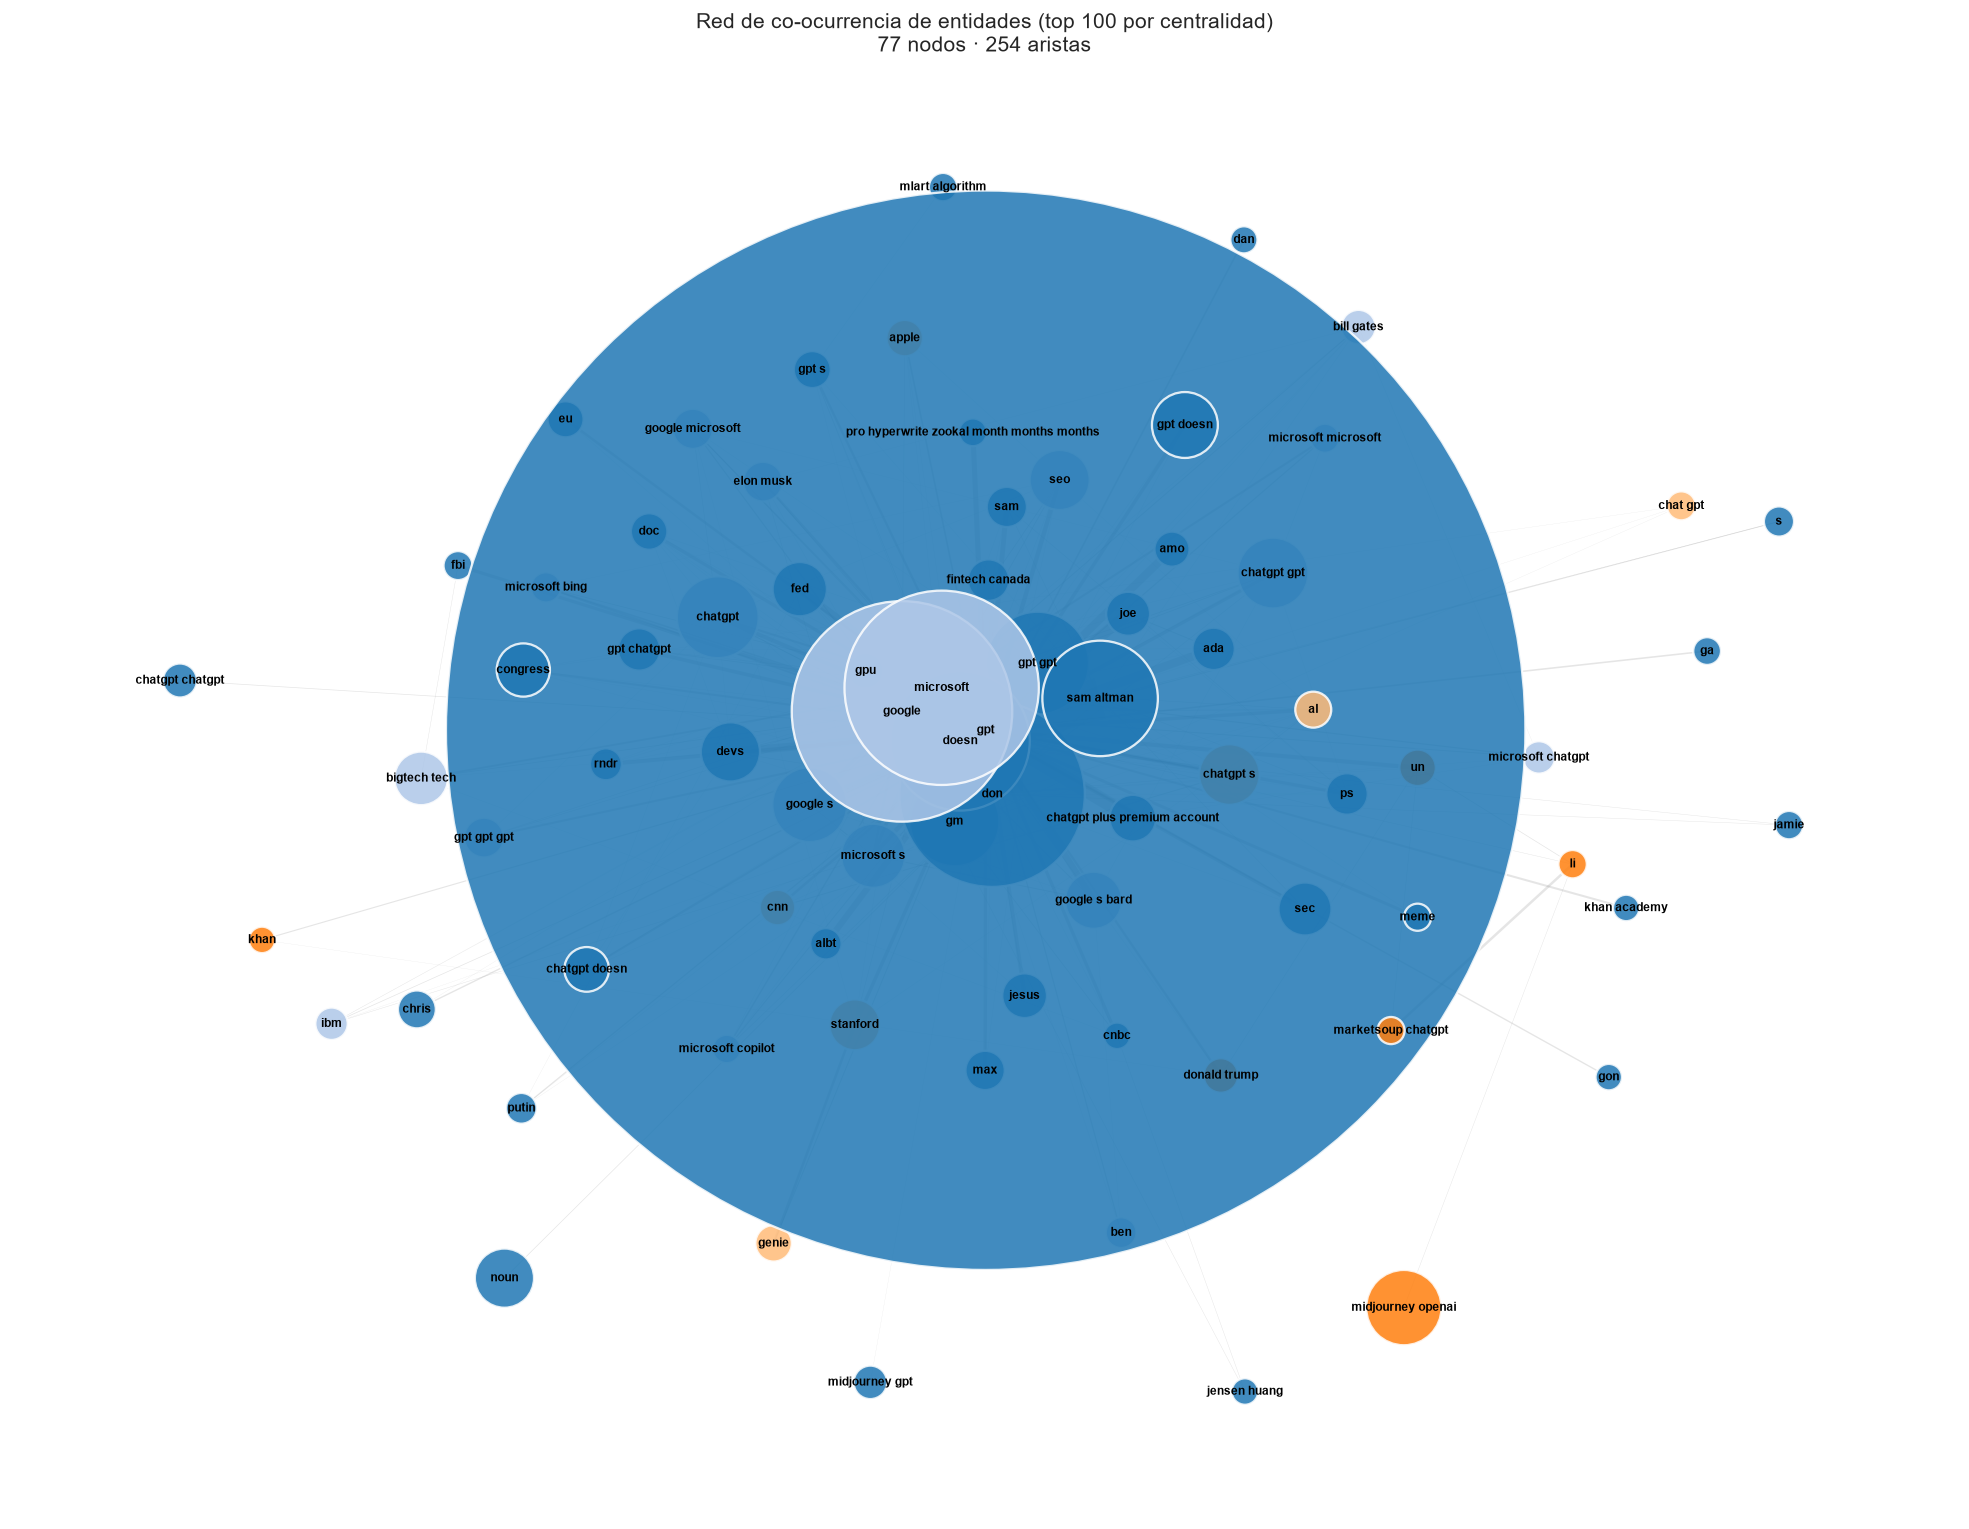

✅ Guardado: C:\Users\jdthg\Documents\curso6BI\reto7_Analisis_datos_no_estructurados\outputs\figuras\06_red_entidades.png


In [11]:
# ============================================
# Visualización de la red (top nodos)
# ============================================
# Subgrafo con top 100 nodos por grado ponderado para visualización
TOP_VIS = 100
top_nodos = df_centralidad.nlargest(TOP_VIS, "grado_ponderado")["entidad"].tolist()
G_vis = G_main.subgraph(top_nodos).copy()

print(f"🎨 Visualizando subgrafo con {G_vis.number_of_nodes()} nodos...")

# Layout
pos = nx.spring_layout(G_vis, k=1.2, iterations=50, seed=42, weight="weight")

# Colores por comunidad
if LOUVAIN_OK:
    comunidades = [G_vis.nodes[n]["comunidad"] for n in G_vis.nodes()]
    cmap = plt.cm.tab20
    colores = [cmap(c % 20) for c in comunidades]
else:
    colores = "skyblue"

# Tamaños por grado ponderado
tamanos = [G_vis.nodes[n]["freq"] * 15 for n in G_vis.nodes()]

# Anchos de aristas por peso
anchos = [G_vis[u][v]["weight"] * 0.15 for u, v in G_vis.edges()]

fig, ax = plt.subplots(figsize=(18, 14))

nx.draw_networkx_edges(
    G_vis, pos,
    alpha=0.2, width=anchos, edge_color="gray", ax=ax,
)
nx.draw_networkx_nodes(
    G_vis, pos,
    node_color=colores, node_size=tamanos,
    alpha=0.85, edgecolors="white", linewidths=1.5, ax=ax,
)
nx.draw_networkx_labels(
    G_vis, pos,
    font_size=8, font_weight="bold", ax=ax,
)

ax.set_title(
    f"Red de co-ocurrencia de entidades (top {TOP_VIS} por centralidad)\n"
    f"{G_vis.number_of_nodes()} nodos · {G_vis.number_of_edges()} aristas",
    fontsize=14,
)
ax.axis("off")
plt.tight_layout()
ruta_fig = FIGURAS / "06_red_entidades.png"
plt.savefig(ruta_fig, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Guardado: {ruta_fig}")

In [12]:
# ============================================
# Palabras clave por comunidad
# ============================================
if LOUVAIN_OK:
    from sklearn.feature_extraction.text import TfidfVectorizer

    print("📊 Extrayendo palabras clave por comunidad...\n")

    # Cargar tweets limpios para unir con las comunidades
    # (asignamos a cada tweet la comunidad de sus entidades más frecuentes)
    resumen_comunidades = []

    for com in sorted(set(particion.values())):
        # Entidades de esta comunidad
        ents_com = df_centralidad[df_centralidad["comunidad"] == com]["entidad"].tolist()
        ents_set = set(ents_com)

        # Textos de tweets que contienen alguna de esas entidades
        textos = []
        for ents in df["entidades_parsed"]:
            if any(e in ents_set for e, _ in ents):
                textos.append(ents)  # no tenemos texto completo aquí

        # Palabras clave = top entidades + tipos
        top_ents = df_centralidad[df_centralidad["comunidad"] == com] \
            .nlargest(10, "grado_ponderado")["entidad"].tolist()

        tipos = df_centralidad[df_centralidad["comunidad"] == com]["tipo"].value_counts()
        tipo_dominante = tipos.idxmax() if len(tipos) > 0 else "N/A"

        resumen_comunidades.append({
            "comunidad": com,
            "n_nodos": len(ents_com),
            "tipo_dominante": tipo_dominante,
            "top_entidades": " | ".join(top_ents[:8]),
        })

    df_resumen_com = pd.DataFrame(resumen_comunidades)
    print("📋 Resumen de comunidades:")
    display(df_resumen_com)

📊 Extrayendo palabras clave por comunidad...

📋 Resumen de comunidades:


,comunidad,n_nodos,tipo_dominante,top_entidades
0,0,45,ORG,gpt | don | doesn | sam altman | gpt gpt | gm | chatgpt plus premium account | joe
1,1,19,ORG,google | microsoft | google s | microsoft s | google s bard | chatgpt | chatgpt gpt | seo
2,2,6,PERSON,un | li | donald trump | marketsoup chatgpt | khan | midjourney openai
3,3,7,ORG,stanford | chatgpt s | al | cnn | genie | apple | chat gpt


📊 Distribución de sentimiento por comunidad (%):
sentimiento_vader  negativo  neutral  positivo
comunidad                                     
0                      16.6     34.9      48.5
1                      19.1     29.4      51.5
2                       8.8     13.0      78.2
3                      15.8     23.5      60.7


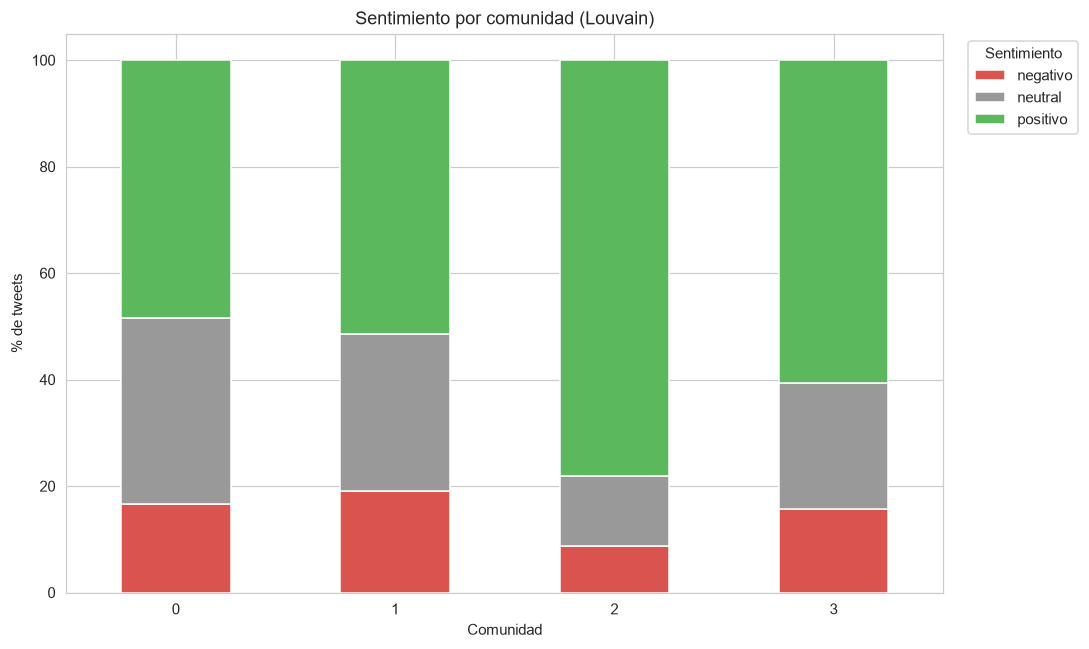

✅ Guardado: C:\Users\jdthg\Documents\curso6BI\reto7_Analisis_datos_no_estructurados\outputs\figuras\06_sentimiento_por_comunidad.png


In [13]:
# ============================================
# Sentimiento por comunidad
# ============================================
if LOUVAIN_OK:
    # Añadir sentimiento del tweet al análisis
    # (trabajamos con df original que tiene sentimiento_vader)
    df_work = df.copy()
    df_work["comunidad"] = None

    # Asignar cada tweet a una comunidad (la de su entidad más frecuente)
    def com_dominante(ents):
        comunidades_tweet = [
            particion[e] for e, _ in ents if e in particion
        ]
        if not comunidades_tweet:
            return None
        return Counter(comunidades_tweet).most_common(1)[0][0]

    df_work["comunidad"] = df_work["entidades_parsed"].apply(com_dominante)
    df_con_com = df_work.dropna(subset=["comunidad"]).copy()
    df_con_com["comunidad"] = df_con_com["comunidad"].astype(int)

    # Cruce
    cruce = pd.crosstab(
        df_con_com["comunidad"],
        df_con_com["sentimiento_vader"],
        normalize="index",
    ) * 100

    print("📊 Distribución de sentimiento por comunidad (%):")
    print(cruce.round(1))

    # Visualización
    fig, ax = plt.subplots(figsize=(10, 6))
    cruce.plot(kind="bar", stacked=True, ax=ax,
               color=["#d9534f", "#999999", "#5cb85c"])
    ax.set_title("Sentimiento por comunidad (Louvain)")
    ax.set_xlabel("Comunidad")
    ax.set_ylabel("% de tweets")
    ax.tick_params(axis="x", rotation=0)
    ax.legend(title="Sentimiento", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    ruta_fig = FIGURAS / "06_sentimiento_por_comunidad.png"
    plt.savefig(ruta_fig, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✅ Guardado: {ruta_fig}")

In [14]:
# ============================================
# Guardar resultados
# ============================================
timestamp = datetime.now().strftime("%Y%m%d")

# --- Nodos (entidades con métricas) ---
ruta_nodos = DATA_PROCESSED / f"red_entidades_nodos_{timestamp}.csv"
df_centralidad.to_csv(ruta_nodos, index=False, encoding="utf-8-sig")
print(f"✅ Guardado: {ruta_nodos}")

# --- Aristas ---
aristas = []
for u, v, data in G_main.edges(data=True):
    aristas.append({
        "entidad_a": u,
        "entidad_b": v,
        "peso": data.get("weight", 1),
    })
df_aristas = pd.DataFrame(aristas).sort_values("peso", ascending=False)
ruta_aristas = DATA_PROCESSED / f"red_entidades_aristas_{timestamp}.csv"
df_aristas.to_csv(ruta_aristas, index=False, encoding="utf-8-sig")
print(f"✅ Guardado: {ruta_aristas}")

# --- Comunidades ---
if LOUVAIN_OK:
    ruta_com = DATA_PROCESSED / f"red_entidades_comunidades_{timestamp}.csv"
    df_resumen_com.to_csv(ruta_com, index=False, encoding="utf-8-sig")
    print(f"✅ Guardado: {ruta_com}")

# --- Formato GEXF para Gephi (opcional, muy útil) ---
try:
    ruta_gexf = DATA_PROCESSED / f"red_entidades_{timestamp}.gexf"
    nx.write_gexf(G_main, ruta_gexf)
    print(f"✅ Guardado (Gephi): {ruta_gexf}")
except Exception as e:
    print(f"⚠️ No se pudo guardar GEXF: {e}")

✅ Guardado: C:\Users\jdthg\Documents\curso6BI\reto7_Analisis_datos_no_estructurados\data\processed\red_entidades_nodos_20260920.csv
✅ Guardado: C:\Users\jdthg\Documents\curso6BI\reto7_Analisis_datos_no_estructurados\data\processed\red_entidades_aristas_20260920.csv
✅ Guardado: C:\Users\jdthg\Documents\curso6BI\reto7_Analisis_datos_no_estructurados\data\processed\red_entidades_comunidades_20260920.csv
✅ Guardado (Gephi): C:\Users\jdthg\Documents\curso6BI\reto7_Analisis_datos_no_estructurados\data\processed\red_entidades_20260920.gexf


In [15]:
# ============================================
# Resumen ejecutivo
# ============================================
lineas = []
lineas.append("# Notebook 06 — Análisis de redes\n")
lineas.append(f"**Fecha:** {datetime.now().strftime('%Y-%m-%d %H:%M')}\n")
lineas.append(f"**Tweets analizados:** {len(df):,}")
lineas.append(f"**Entidades consideradas:** {len(entidades_validas):,} (freq ≥ {MIN_FREQ})")
lineas.append(f"**Nodos en la red:** {G.number_of_nodes():,}")
lineas.append(f"**Aristas:** {G.number_of_edges():,}")
lineas.append(f"**Densidad:** {nx.density(G):.5f}")
lineas.append(f"**Componente gigante:** {G_main.number_of_nodes():,} nodos")

if LOUVAIN_OK:
    lineas.append(f"**Comunidades:** {n_comunidades}")
    lineas.append(f"**Modularidad:** {modularidad:.3f}")

lineas.append("\n## Top 10 entidades por centralidad\n")
top10 = df_centralidad.nlargest(10, "grado_ponderado")[["entidad", "tipo", "freq", "grado_ponderado"]]
lineas.append(top10.to_string(index=False))

if LOUVAIN_OK:
    lineas.append("\n## Comunidades detectadas\n")
    for _, row in df_resumen_com.iterrows():
        lineas.append(f"\n**Comunidad {row['comunidad']}** ({row['n_nodos']} nodos, tipo dominante: {row['tipo_dominante']})")
        lineas.append(f"Top entidades: {row['top_entidades']}")

reporte = "\n".join(lineas)
ruta_reporte = REPORTES / f"06_redes_resumen_{timestamp}.md"
ruta_reporte.write_text(reporte, encoding="utf-8")
print(f"✅ Reporte guardado: {ruta_reporte}\n")
print(reporte[:2500])

✅ Reporte guardado: C:\Users\jdthg\Documents\curso6BI\reto7_Analisis_datos_no_estructurados\outputs\reportes\06_redes_resumen_20260920.md

# Notebook 06 — Análisis de redes

**Fecha:** 2026-09-20 20:01

**Tweets analizados:** 100,000
**Entidades consideradas:** 84 (freq ≥ 20)
**Nodos en la red:** 84
**Aristas:** 254
**Densidad:** 0.07286
**Componente gigante:** 77 nodos
**Comunidades:** 4
**Modularidad:** 0.094

## Top 10 entidades por centralidad

                     entidad    tipo  freq  grado_ponderado
                         gpt     ORG 33279             2344
                      google     ORG  1389              521
                   microsoft     ORG  1079              447
                         don  PERSON   982              342
                       doesn  PERSON   554              242
                  sam altman  PERSON   381              206
                     gpt gpt     ORG   302              157
                          gm     ORG   229              133
       